In [ ]:
from google.colab import files
uploaded = files.upload()

Saving constituency_master.csv to constituency_master.csv
Saving tn_2021_results.csv to tn_2021_results.csv
Saving tn_2026_results.csv to tn_2026_results.csv


In [ ]:
import pandas as pd

df26 = pd.read_csv('tn_2026_results.csv')
df21 = pd.read_csv('tn_2021_results.csv')
master = pd.read_csv('constituency_master.csv')

print(df26.shape)
print(df21.shape)
print(master.shape)

(4257, 8)
(4232, 8)
(234, 5)


In [ ]:
# Get winner per constituency for each year
# Logic: winner = candidate with max votes in each AC

idx26 = df26.groupby('ac_number')['votes'].idxmax()
idx21 = df21.groupby('ac_number')['votes'].idxmax()

w26 = df26.loc[idx26][['ac_number','constituency','region','reserved','party','votes']].copy()
w26.columns = ['ac_number','constituency','region','reserved','winner_2026','votes_2026']

w21 = df21.loc[idx21][['ac_number','party','votes']].copy()
w21.columns = ['ac_number','winner_2021','votes_2021']

# Join both years into one table
seats = w26.merge(w21, on='ac_number')

print(seats.shape)
print(seats.head())

(234, 8)
   ac_number   constituency         region reserved winner_2026  votes_2026  \
0          1  Gummidipoondi  Chennai Metro      GEN         TVK       94320   
1          2        Ponneri  Chennai Metro       SC         TVK      110439   
2          3      Tiruttani  Chennai Metro      GEN      AIADMK       89169   
3          4    Thiruvallur  Chennai Metro      GEN         TVK       92190   
4          5    Poonamallee  Chennai Metro       SC         TVK      161309   

  winner_2021  votes_2021  
0         DMK      126452  
1         INC       94528  
2         DMK      120314  
3         DMK      107709  
4         DMK      149578  


In [ ]:
# Flag seats that changed hands
seats['flipped'] = seats['winner_2026'] != seats['winner_2021']

# Calculate total valid votes per AC (excluding NOTA)
tv26 = df26[df26['party'] != 'NOTA'].groupby('ac_number')['votes'].sum().reset_index()
tv26.columns = ['ac_number', 'total_valid_2026']

tv21 = df21[df21['party'] != 'NOTA'].groupby('ac_number')['votes'].sum().reset_index()
tv21.columns = ['ac_number', 'total_valid_2021']

# Add to seats table
seats = seats.merge(tv26, on='ac_number').merge(tv21, on='ac_number')

# Win percentage for each year
seats['win_pct_2026'] = (seats['votes_2026'] / seats['total_valid_2026'] * 100).round(1)
seats['win_pct_2021'] = (seats['votes_2021'] / seats['total_valid_2021'] * 100).round(1)

# Quick summary
print("Total seats:", len(seats))
print("Seats that flipped:", seats['flipped'].sum())
print("Seats retained:", (~seats['flipped']).sum())
print("\nAvg win % 2026:", seats['win_pct_2026'].mean().round(1))
print("Avg win % 2021:", seats['win_pct_2021'].mean().round(1))

Total seats: 234
Seats that flipped: 163
Seats retained: 71

Avg win % 2026: 39.0
Avg win % 2021: 48.8


In [ ]:
# Which party lost seats to which party
flips = seats[seats['flipped']][['winner_2021','winner_2026']].value_counts().reset_index()
flips.columns = ['from_party', 'to_party', 'seats_flipped']

print(flips.to_string())

   from_party to_party  seats_flipped
0         DMK      TVK             65
1      AIADMK      TVK             26
2         DMK   AIADMK             22
3      AIADMK      DMK             15
4         INC      TVK             11
5         DMK      PMK              3
6         BJP      DMK              2
7         PMK   AIADMK              2
8         PMK      TVK              2
9         BJP      TVK              2
10     AIADMK      INC              1
11     AIADMK      VCK              1
12     AIADMK     IUML              1
13        DMK   CPI(M)              1
14     CPI(M)      TVK              1
15        INC      BJP              1
16        DMK     IUML              1
17        DMK     AMMK              1
18        INC      DMK              1
19        INC     DMDK              1
20        VCK   AIADMK              1
21        VCK      DMK              1
22        VCK      TVK              1


In [ ]:
regions = ['Chennai Metro', 'North', 'Central', 'Kongu', 'Delta', 'South']
focus_26 = ['TVK', 'DMK', 'AIADMK']
focus_21 = ['DMK', 'AIADMK']

# 2026 regional vote shares
tv26_reg = df26[df26['party'] != 'NOTA'].groupby('region')['votes'].sum()
vs26 = df26[df26['party'].isin(focus_26)].groupby(['region','party'])['votes'].sum()
vs26 = (vs26 / tv26_reg * 100).round(1).reset_index()
vs26.columns = ['region', 'party', 'vote_share']

# 2021 regional vote shares
tv21_reg = df21[df21['party'] != 'NOTA'].groupby('region')['votes'].sum()
vs21 = df21[df21['party'].isin(focus_21)].groupby(['region','party'])['votes'].sum()
vs21 = (vs21 / tv21_reg * 100).round(1).reset_index()
vs21.columns = ['region', 'party', 'vote_share']

# State-wide totals
tw26 = df26[df26['party'] != 'NOTA']['votes'].sum()
tw21 = df21[df21['party'] != 'NOTA']['votes'].sum()

print("=== 2026 state-wide ===")
for p in focus_26:
    pv = df26[df26['party']==p]['votes'].sum()
    print(f"{p}: {pv/tw26*100:.1f}%")

print("\n=== 2021 state-wide ===")
for p in focus_21:
    pv = df21[df21['party']==p]['votes'].sum()
    print(f"{p}: {pv/tw21*100:.1f}%")

print("\n=== 2026 by region ===")
print(vs26.pivot(index='region', columns='party', values='vote_share').fillna(0))

print("\n=== 2021 by region ===")
print(vs21.pivot(index='region', columns='party', values='vote_share').fillna(0))

=== 2026 state-wide ===
TVK: 35.1%
DMK: 24.3%
AIADMK: 21.3%

=== 2021 state-wide ===
DMK: 38.0%
AIADMK: 33.5%

=== 2026 by region ===
party          AIADMK   DMK   TVK
region                           
Central          27.1  23.3  31.1
Chennai Metro    16.0  24.4  46.9
Delta            19.6  27.8  33.0
Kongu            24.0  25.7  34.7
North            25.0  20.6  33.2
South            16.9  24.7  33.6

=== 2021 by region ===
party          AIADMK   DMK
region                     
Central          35.8  39.2
Chennai Metro    28.6  45.7
Delta            33.8  40.9
Kongu            39.8  34.7
North            32.0  37.2
South            32.0  33.4


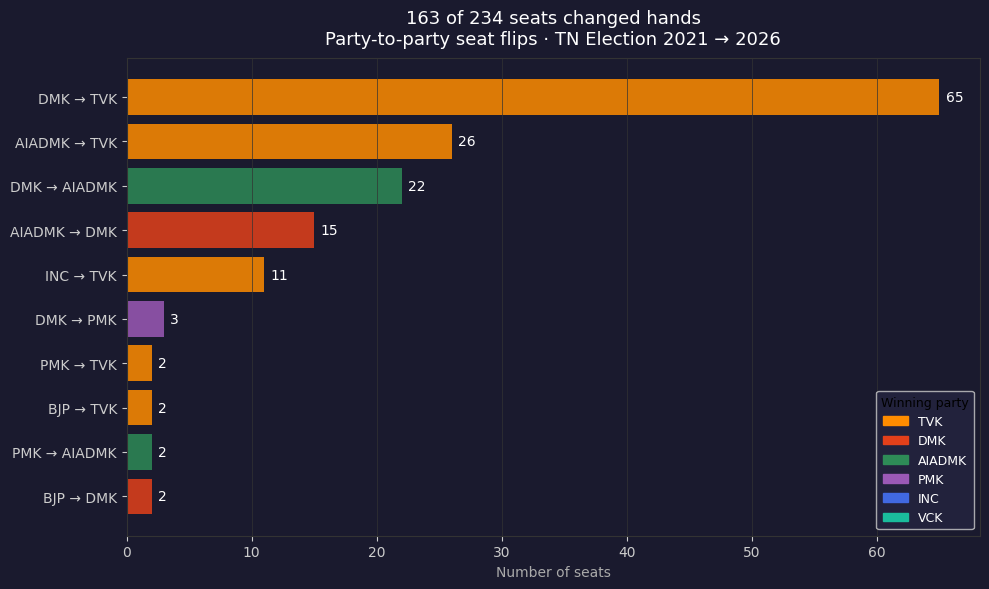

Chart saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Filter to major flows only
major_flips = flips[flips['seats_flipped'] >= 2].copy()
major_flips['label'] = major_flips['from_party'] + ' → ' + major_flips['to_party']
major_flips = major_flips.sort_values('seats_flipped', ascending=True)

# Color bars by destination party
party_colors = {
    'TVK': '#FF8C00', 'DMK': '#E3401A', 'AIADMK': '#2E8B57',
    'PMK': '#9B59B6', 'INC': '#4169E1', 'VCK': '#1ABC9C'
}
bar_colors = [party_colors.get(p, '#888888') for p in major_flips['to_party']]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars = ax.barh(major_flips['label'], major_flips['seats_flipped'],
               color=bar_colors, alpha=0.85)

# Value labels
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', color='white', fontsize=10)

ax.set_xlabel('Number of seats', color='#aaa')
ax.set_title('163 of 234 seats changed hands\nParty-to-party seat flips · TN Election 2021 → 2026',
             color='white', fontsize=13, pad=10)
ax.tick_params(colors='#ccc')
ax.spines[['top','right','left','bottom']].set_color('#333')
ax.grid(axis='x', color='#333', lw=0.5)

# Legend
legend_patches = [mpatches.Patch(color=c, label=p) for p, c in party_colors.items()]
ax.legend(handles=legend_patches, title='Winning party', facecolor='#252540',
          labelcolor='white', title_fontsize=9, fontsize=9,
          framealpha=0.8)

plt.tight_layout()
plt.savefig('chart_q2_flips.png', dpi=180, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Chart saved!")

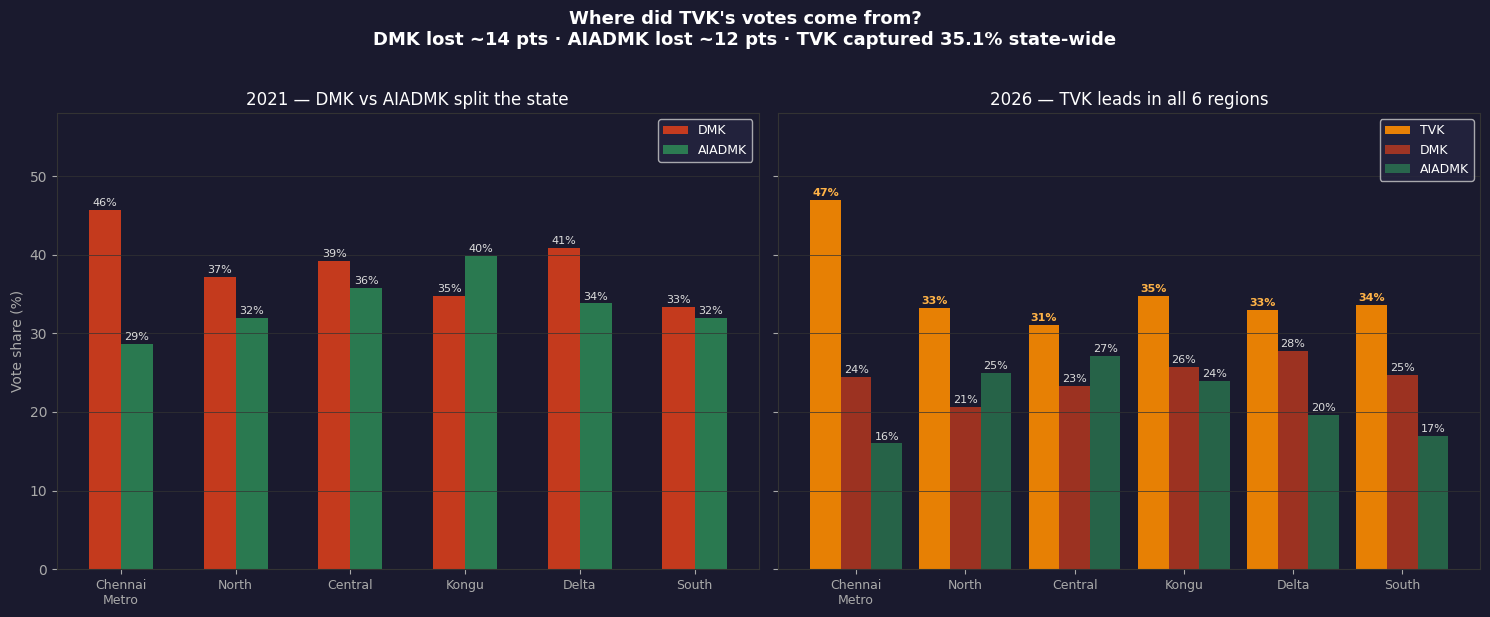

Chart saved!


In [ ]:
regions = ['Chennai Metro', 'North', 'Central', 'Kongu', 'Delta', 'South']

# Data from what we already calculated
dmk_21  = [45.7, 37.2, 39.2, 34.7, 40.9, 33.4]
aia_21  = [28.6, 32.0, 35.8, 39.8, 33.8, 32.0]
tvk_26  = [46.9, 33.2, 31.1, 34.7, 33.0, 33.6]
dmk_26  = [24.4, 20.6, 23.3, 25.7, 27.8, 24.7]
aia_26  = [16.0, 25.0, 27.1, 24.0, 19.6, 16.9]

x = np.arange(len(regions))
w = 0.28

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
fig.patch.set_facecolor('#1a1a2e')

# --- 2021 panel ---
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
b1 = ax1.bar(x - w/2, dmk_21, w, color='#E3401A', alpha=0.85, label='DMK')
b2 = ax1.bar(x + w/2, aia_21, w, color='#2E8B57', alpha=0.85, label='AIADMK')
for bar in list(b1)+list(b2):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{bar.get_height():.0f}%', ha='center', fontsize=8, color='#ddd')
ax1.set_xticks(x)
ax1.set_xticklabels([r.replace(' ','\n') for r in regions], color='#ccc', fontsize=9)
ax1.set_ylabel('Vote share (%)', color='#aaa')
ax1.set_ylim(0, 58)
ax1.set_title('2021 — DMK vs AIADMK split the state', color='white', fontsize=12)
ax1.legend(facecolor='#252540', labelcolor='white', fontsize=9)
ax1.tick_params(colors='#aaa')
ax1.spines[['top','right','left','bottom']].set_color('#333')
ax1.grid(axis='y', color='#333', lw=0.5)

# --- 2026 panel ---
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
b3 = ax2.bar(x - w, tvk_26, w, color='#FF8C00', alpha=0.9,  label='TVK')
b4 = ax2.bar(x,     dmk_26, w, color='#E3401A', alpha=0.65, label='DMK')
b5 = ax2.bar(x + w, aia_26, w, color='#2E8B57', alpha=0.65, label='AIADMK')
for bar in list(b3):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{bar.get_height():.0f}%', ha='center', fontsize=8,
             color='#FFB347', fontweight='bold')
for bar in list(b4)+list(b5):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{bar.get_height():.0f}%', ha='center', fontsize=8, color='#ddd')
ax2.set_xticks(x)
ax2.set_xticklabels([r.replace(' ','\n') for r in regions], color='#ccc', fontsize=9)
ax2.set_title('2026 — TVK leads in all 6 regions', color='white', fontsize=12)
ax2.legend(facecolor='#252540', labelcolor='white', fontsize=9)
ax2.tick_params(colors='#aaa')
ax2.spines[['top','right','left','bottom']].set_color('#333')
ax2.grid(axis='y', color='#333', lw=0.5)

fig.suptitle("Where did TVK's votes come from?\nDMK lost ~14 pts · AIADMK lost ~12 pts · TVK captured 35.1% state-wide",
             color='white', fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart_q3_voteshare.png', dpi=180, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Chart saved!")

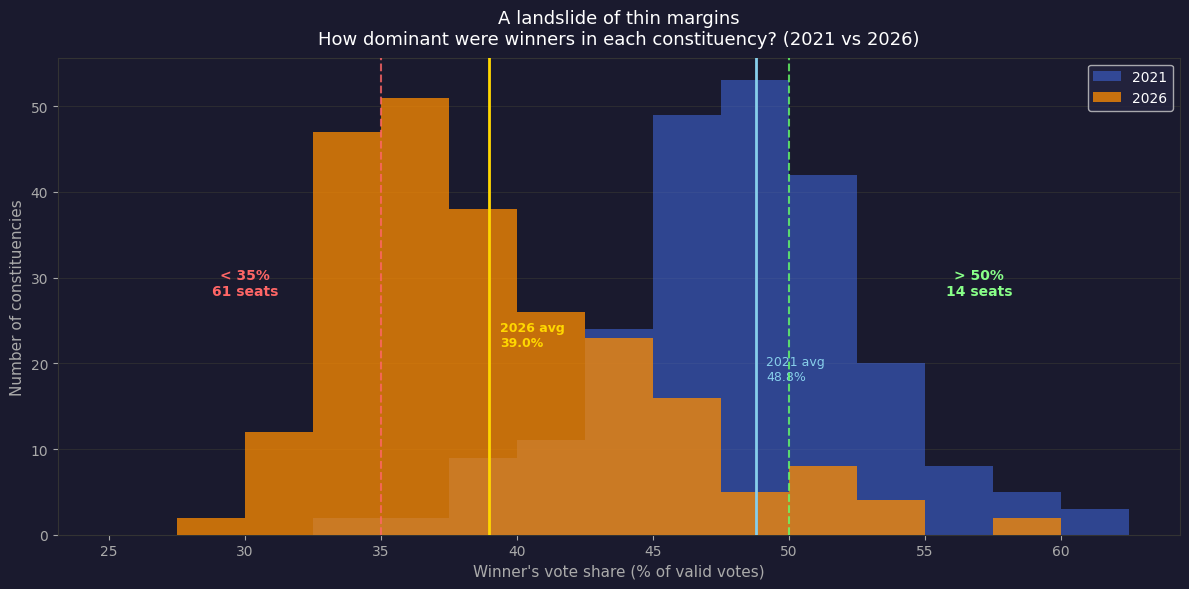

Chart saved!


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bins = np.arange(25, 65, 2.5)

ax.hist(seats['win_pct_2021'], bins=bins, color='#4169E1', alpha=0.55, label='2021', zorder=2)
ax.hist(seats['win_pct_2026'], bins=bins, color='#FF8C00', alpha=0.75, label='2026', zorder=3)

# Zone lines
ax.axvline(35, color='#FF6666', lw=1.5, ls='--', alpha=0.8, zorder=4)
ax.axvline(50, color='#66FF66', lw=1.5, ls='--', alpha=0.8, zorder=4)

# Zone labels
ax.text(30, 28, f"< 35%\n{(seats.win_pct_2026 < 35).sum()} seats",
        ha='center', fontsize=10, color='#FF6666', fontweight='bold')
ax.text(57, 28, f"> 50%\n{(seats.win_pct_2026 > 50).sum()} seats",
        ha='center', fontsize=10, color='#88FF88', fontweight='bold')

# Average lines
ax.axvline(seats['win_pct_2026'].mean(), color='#FFD700', lw=2, zorder=5)
ax.axvline(seats['win_pct_2021'].mean(), color='#87CEEB', lw=2, zorder=5)

ax.text(seats['win_pct_2026'].mean()+0.4, 22,
        f"2026 avg\n{seats['win_pct_2026'].mean():.1f}%",
        fontsize=9, color='#FFD700', fontweight='bold')
ax.text(seats['win_pct_2021'].mean()+0.4, 18,
        f"2021 avg\n{seats['win_pct_2021'].mean():.1f}%",
        fontsize=9, color='#87CEEB')

ax.set_xlabel("Winner's vote share (% of valid votes)", color='#aaa', fontsize=11)
ax.set_ylabel('Number of constituencies', color='#aaa', fontsize=11)
ax.set_title("A landslide of thin margins\nHow dominant were winners in each constituency? (2021 vs 2026)",
             color='white', fontsize=13, pad=10)
ax.legend(facecolor='#252540', labelcolor='white', fontsize=10)
ax.tick_params(colors='#aaa')
ax.spines[['top','right','left','bottom']].set_color('#333')
ax.grid(axis='y', color='#333', lw=0.5)

plt.tight_layout()
plt.savefig('chart_q6_margins.png', dpi=180, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Chart saved!")

In [ ]:
from google.colab import files
files.download('chart_q2_flips.png')
files.download('chart_q3_voteshare.png')
files.download('chart_q6_margins.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>